In [107]:
import glob
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import numpy as np

from collections import defaultdict

sns.set_theme(style="whitegrid")

In [3]:
def parse_stats_file(stats_path):
    results = defaultdict(list)
    with open(stats_path, 'r') as stream:
        for line in stream:
            if line.startswith("#= Summary for dataset:"):
                datapath = line.split()[-1]
            if "level" in line:
                level, stats = line.split("level:")
                results["datapath"].append(datapath)
                results["level"].append(level.strip())
                results["sensitivity"].append(float(stats.split()[0]))
                results["precision"].append(float(stats.split()[2]))
    return pd.DataFrame.from_dict(results)

In [4]:
stats_paths = glob.glob("../../../../alt_transcript_data/*/gffcmp*/gffcmp.stats")
dfs = []
for path in stats_paths:
    stats_df = parse_stats_file(path)
    stats_df["species"] = stats_df["datapath"].str.split('/').str[-2]
    stats_df["dataset"] = stats_df["datapath"].str.split('/').str[-1].str.replace(".gff3", "")
    dfs.append(stats_df)
all_stats = pd.concat(dfs)
all_stats = all_stats.sort_values(["species", "dataset", "level"])

all_stats["dataset"] = pd.Categorical(all_stats["dataset"], categories=["geneml", "augustus"], ordered=True)

In [5]:
transcript_stats = all_stats[all_stats["level"] == "Transcript"]
transcript_stats = transcript_stats.melt(id_vars=["species", "dataset"], value_vars=["sensitivity", "precision"], var_name="metric", value_name="value")

In [ ]:
counts_paths = glob.glob("../../../../alt_transcript_data/*/transcript_counts.tsv")
dfs = []
for path in counts_paths:
    counts_df = pd.read_csv(path, sep="\t")
    counts_df["species"] = path.split("/")[-2]
    dfs.append(counts_df)
counts = pd.concat(dfs)

In [55]:
counts_binned = (
    counts.assign(
        Transcripts_per_locus_bin=counts["Transcripts_per_locus"].where(
            counts["Transcripts_per_locus"] < 10,
            ">10"
        )
    )
    .groupby(["species", "Transcripts_per_locus_bin"], as_index=False)["Count"]
    .sum()
)

/tmp/ipykernel_1673/2300696922.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


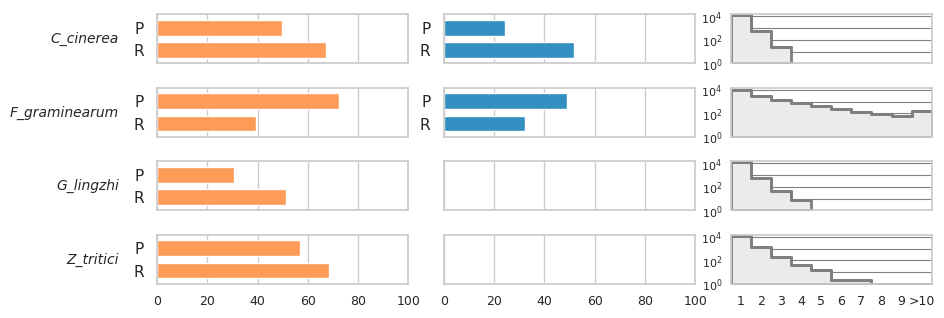

In [127]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

species_order = transcript_stats["species"].unique()
datasets = transcript_stats["dataset"].cat.categories

fig = plt.figure(figsize=(10, 3.5))

gs = gridspec.GridSpec(
    nrows=len(species_order),
    ncols=3,
    wspace=0.15,
    hspace=0.5,
    width_ratios=[1, 1, 0.8]
)

hist_axes = []

for i, species in enumerate(species_order):

    # ---- Plot 1: one column per dataset ----
    for j, dataset in enumerate(datasets):

        data = transcript_stats[
                        (transcript_stats["species"] == species) &
                        (transcript_stats["dataset"] == dataset)
                    ]

        ax = fig.add_subplot(gs[i, j])

        sns.barplot(
            data=data,
            x="value",
            y="metric",
            width=0.7,
            color=["#FF9B59", "#338EC1"][j],
            ax=ax,
            saturation=1,
        )

        ax.set_xlim(0, 100)
        ax.set_ylim(-0.6, 1.6)

        if len(data) > 0:
            ax.set_yticks(range(2))
            ax.set_yticklabels(["R", "P"])
        else:
            ax.set_yticks([])
            ax.set_ylabel("")

        # only show x tick labels on bottom row
        if i < len(species_order)-1:
            ax.set_xticklabels([])

        ax.set_xlabel("")
        ax.set_ylabel("")


    # ---- Plot 2: histogram ----
    ax = fig.add_subplot(gs[i, 2])
    hist_axes.append(ax)

    data = counts_binned[
        counts_binned["species"] == species
    ].copy()

    # numeric positions for categorical bins
    data["x"] = range(len(data))

    x = data["x"].to_numpy()
    y = data["Count"].to_numpy()

    # add edge points so first and last bins have full width
    x_step = np.r_[x[0] - 0.5, x, x[-1] + 0.5]
    y_step = np.r_[y[0], y, y[-1]]

    ax.step(
        x_step,
        y_step,
        where="mid",
        color="#7E7E7E",
        linewidth=2,
    )

    ax.fill_between(
        x_step,
        y_step,
        1,
        step="mid",
        color="#EBEBEB",
        edgecolor="#7E7E7E",
        linewidth=2,
    )

    ax.set_yscale("log")
    ax.set_ylim(1, 15000)

    ax.set_yticks([1, 10, 100, 1000, 10000])
    ax.set_yticklabels([
        r"$10^0$", "", r"$10^2$", "", r"$10^4$"
    ])

    ax.tick_params(axis="y", labelsize=8, pad=0)

    ax.grid(
        which="major",
        axis="y",
        linewidth=0.8,
        color="gray",
    )

    ax.grid(
        which="major",
        axis="x",
        visible=False,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    # species label on first column
    fig.axes[-3].text(
        -0.15, 0.5, species,
        transform=fig.axes[-3].transAxes,
        va="center",
        ha="right",
        fontsize=10,
        fontstyle="italic",
    )

for ax in hist_axes[1:]:
    ax.sharex(hist_axes[0])

hist_axes[0].set_xlim(
    -0.5,
    len(data["Transcripts_per_locus_bin"]) - 0.5
)

# hide upper x tick labels
for ax in hist_axes[:-1]:
    ax.tick_params(axis="x", labelbottom=False, length=0)

# restore bottom x tick labels
hist_axes[-1].set_xticks(range(len(data["Transcripts_per_locus_bin"])))
hist_axes[-1].set_xticklabels(data["Transcripts_per_locus_bin"])

for ax in fig.axes:
    ax.tick_params(axis="x", labelsize=9, pad=2)

plt.tight_layout()

In [ ]:
class_counts_paths = glob.glob("../../../../alt_transcript_data/*/alt_transcript_counts*")
dfs = []
for path in class_counts_paths:
    counts_df = pd.read_csv(path, sep="\t")
    counts_df["species"] = path.split("/")[-2]
    counts_df["dataset"] = path.split("/")[-1].replace("alt_transcript_counts_", "").replace(".tsv", "")
    dfs.append(counts_df)
counts = pd.concat(dfs)